In [2]:
import os
import load_dotenv
from load_dotenv import load_dotenv

# This function will load all the variable from the .env file and 
# make them available in the os.environ dictionary (env variables)
load_dotenv()

if os.environ.get("CLAUDE_API_KEY"):
    print("CLAUDE API KEY has been loaded")
else:
    raise ValueError("CLAUDE API KEY not found")

if os.environ.get("TAVILY_API_KEY"):
    print("TAVILY API KEY has been loaded")
else:
    raise ValueError("TAVILY API KEY not found")

CLAUDE API KEY has been loaded
TAVILY API KEY has been loaded


In [3]:
from langchain_anthropic import ChatAnthropic

llm_anthropic = ChatAnthropic(
    model = os.environ.get("CLAUDE_MODEL"),
    api_key = os.environ.get('CLAUDE_API_KEY'),
    temperature = 0,
    base_url = os.environ.get("CLAUDE_BASE_URL")
)
llm_anthropic

ChatAnthropic(metadata={'lc_versions': {'langchain-core': '1.5.4', 'langchain': '1.3.15', 'langchain-anthropic': '1.5.5'}}, model='vertex_ai.anthropic.claude-opus-4-6', max_tokens=4096, temperature=0.0, anthropic_api_url='https://genai-sharedservice-americas.pwcinternal.com', anthropic_api_key=SecretStr('**********'), model_kwargs={})

#### Pydantic LLM Schema

In [6]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not funny"] = Field(..., description="Whether the joke is funny or not.")
    feedback: str = Field(description="Feedback on the joke")
    
llm_with_schema = llm_anthropic.with_structured_output(llm_schema)


#### Graph Schema

In [7]:
class graph_schema(TypedDict):

    topic: str
    joke: str
    funny_flag: str
    feedback: str
    max_iterations: str

#### Nodes

In [11]:
def generate_node(state: graph_schema) -> graph_schema:

    topic = state['topic']

    if state['feedback']:  # Further Iterations
        response = llm_anthropic.invoke(f"Please modify the following joke {state['joke']} based on the following feedback {state['feedback']}")
    else:  # First iteration, generate a joke
        response = llm_anthropic.invoke(f"Create a joke about the following topic {topic}")

    state['joke'] = response.content
    return state

#### Creating Evaluator Node

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

def evaluate_node(state: graph_schema) -> graph_schema:

    joke = state['joke']
    iteration = state['max_iterations']

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a comedy critic. Your job is to evaluate the following joke and provide feedback on how to make it funnier."),
        ("user", f"Evaluate the following joke: {joke}\n Respond with 'funny' or 'not_funny' and provide feedback if it's not funny.")
        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    state['funny_flag'] = response.funny_flag
    state['feedback'] = response.feedback
    state['max_iterations'] = iteration + 1

    return state

#### Conditional Edge function

In [ ]:
def check_iteration(state: graph_schema) -> str:

    iteration = state['max_iterations']

    if iteration <= 5 and state['funny_flag'] != "funny":
        return "evaluate_node"
    else:
        return "end"

#### Creating StateGraph

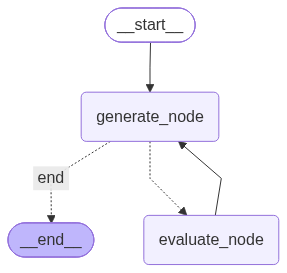

In [16]:
from langgraph.graph import StateGraph, START, END 
from IPython.display import Image, display

graph = StateGraph(graph_schema)

# Adding nodes to the Graph
graph.add_node("generate_node", generate_node)
graph.add_node("evaluate_node", evaluate_node)

# Adding edges to the Graph
graph.add_edge(START, "generate_node")
graph.add_conditional_edges("generate_node", check_iteration, {"evaluate_node": "evaluate_node", "end": END})
graph.add_edge("evaluate_node", "generate_node")
graph.add_edge("generate_node", END)

ge_graph = graph.compile()

Image(ge_graph.get_graph().draw_mermaid_png())

#### Invoke Graph

In [ ]:
ge_graph.invoke(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    }
)

In [ ]:
for chunk in ge_graph.stream(
    {
        "topic": "Cars",
        "joke": "",
        "funny_flag": "",
        "feedback": "",
        "max_iterations": 0
    },
    stream_mode = "updates"
):
    print(chunk)